In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# Set aesthetic styling for plots
sns.set_theme(style="whitegrid")

In [4]:
df = pd.read_csv('clean_sets/features_extracted.csv')

features = [
    'population_density', 
    'accessibility_score', 
    'competitor_density', 
    'distance_to_main_road', 
    'distance_to_nearest_supermarket'
]
X = df[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [5]:
best_k = 2
best_score = -1
scores = []

print("Testing K-Means configurations...")
for k in range(2, 9):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    scores.append(score)
    print(f"Clusters: {k} | Silhouette Score: {score:.4f}")
    
    if score > best_score:
        best_score = score
        best_k = k

print(f"\nOptimal Clusters (k): {best_k} with a score of {best_score:.4f}")

Testing K-Means configurations...
Clusters: 2 | Silhouette Score: 0.3689
Clusters: 3 | Silhouette Score: 0.3522
Clusters: 4 | Silhouette Score: 0.3762
Clusters: 5 | Silhouette Score: 0.3335
Clusters: 6 | Silhouette Score: 0.3380
Clusters: 7 | Silhouette Score: 0.3246
Clusters: 8 | Silhouette Score: 0.2923

Optimal Clusters (k): 4 with a score of 0.3762


In [6]:
final_kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df['Cluster'] = final_kmeans.fit_predict(X_scaled)

print("Point Distribution across Zones:")
print(df['Cluster'].value_counts().sort_index())

Point Distribution across Zones:
Cluster
0    2501
1    1134
2     844
3    3624
Name: count, dtype: int64


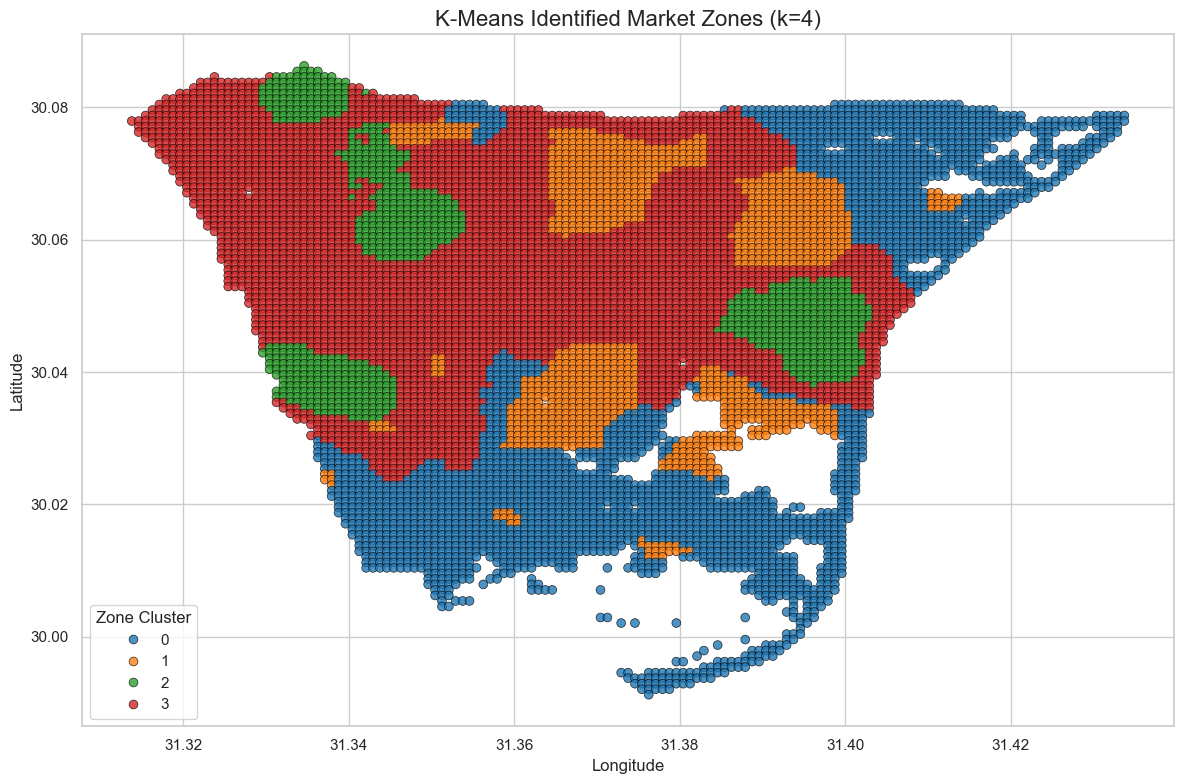

In [7]:
plt.figure(figsize=(12, 8))

sns.scatterplot(data=df, x='longitude', y='latitude', 
                hue='Cluster', palette='tab10', s=40, edgecolor='black', alpha=0.8)

plt.title(f'K-Means Identified Market Zones (k={best_k})', fontsize=16)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend(title='Zone Cluster')
plt.tight_layout()
plt.show()

C:\Users\win  10\AppData\Local\Temp\ipykernel_14024\4169590619.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Cluster', y='population_density', ax=axes[0], palette='tab10')
C:\Users\win  10\AppData\Local\Temp\ipykernel_14024\4169590619.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Cluster', y='competitor_density', ax=axes[1], palette='tab10')


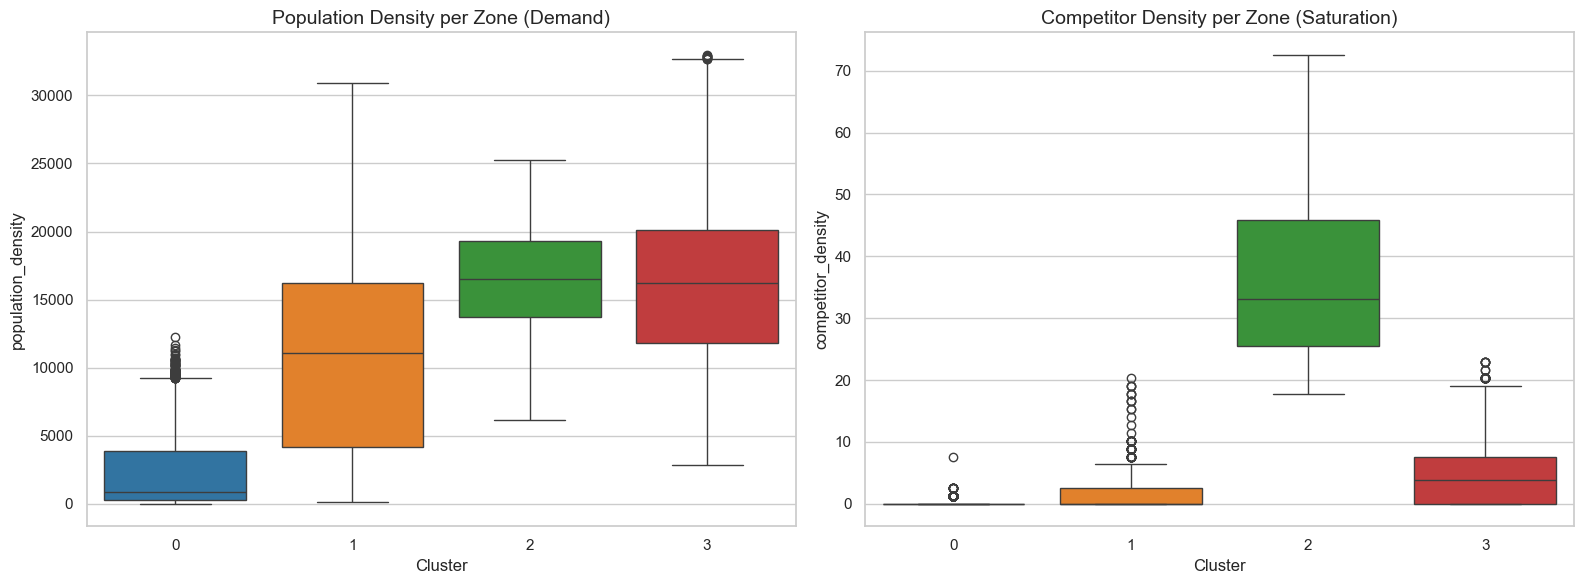


Mean feature values for K-Means clusters:
         population_density  accessibility_score  competitor_density  distance_to_main_road  distance_to_nearest_supermarket
Cluster                                                                                                                     
0                 2407.2061               0.3441              0.0916                 0.2259                           2.0626
1                11366.2447               0.2948              1.4383                 0.6389                           0.8063
2                16426.4928               0.6306             36.4699                 0.2847                           0.1732
3                16349.3636               0.5656              4.8987                 0.1816                           0.5143


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Population Density Comparison
sns.boxplot(data=df, x='Cluster', y='population_density', ax=axes[0], palette='tab10')
axes[0].set_title('Population Density per Zone (Demand)', fontsize=14)

# Competitor Density Comparison
sns.boxplot(data=df, x='Cluster', y='competitor_density', ax=axes[1], palette='tab10')
axes[1].set_title('Competitor Density per Zone (Saturation)', fontsize=14)

plt.tight_layout()
plt.show()

# Print the raw means for the final report
print("\nMean feature values for K-Means clusters:")
print(df.groupby('Cluster')[features].mean().round(4).to_string())